# Compare Event Selection for Detector Variation Samples

- Note: This **needs** EAF resources, don't run on gpvms

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial


# local imports
import sys
# sys.path.append('../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
import matplotlib as mpl
plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

mc_n_split: 1
mc_tot_pot: 1.518e+19
Integrated flux: 2.452e+11
# of targets:  1.3251484770937053e+30
xsec unit:  3.0775821542623837e-42


In [5]:
data = True
if data:
    data_file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
    data_file = path.join(data_file_dir, "data", "BNB", "all.df")
    data_split_df = pd.read_hdf(data_file, key="split")
    data_n_split = get_n_split(data_file)
    print("data_n_split: %d" %(data_n_split))
    print_keys(data_file)
    data_keys2load = ['evt', 'hdr', 'bnbpot', 'trk']
    data_dfs = load_dfs(data_file, data_keys2load, n_max_concat=5)
    data_evt_df = data_dfs['evt']
    data_trk_df = data_dfs['trk']
    data_hdr_df = data_dfs['hdr']
    data_bnbpot_df = data_dfs['bnbpot']
    data_tot_pot = data_hdr_df['pot'].sum()

data_n_split: 2
Keys: ['/bnbpot_0', '/bnbpot_1', '/evt_0', '/evt_1', '/hdr_0', '/hdr_1', '/histgenevtdf_0', '/histgenevtdf_1', '/histpotdf_0', '/histpotdf_1', '/split', '/trk_0', '/trk_1']


In [21]:
# variations
this_variation = "WireMod"
syst_keys = ["CV", "WireMod_XThetaXW", "WireMod_YZ"]
labels    = ["CV", r"X-$\theta_{xw}$", r"Y-Z"]

# this_variation = "SCE"
# syst_keys = ["CV", "0xSCE", "2xSCE"]
# labels    = ["CV", r"0xSCE", r"2xSCE"]

colors    = ["black", "C0", "C1"]

detvar_plotter = partial(
    variation_hists,
    var_colors=colors,
    var_labels=labels,
    approval="internal"
)

In [22]:
save_result = True
save_fig = save_result

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"systematics-detvar_wdata-{this_variation}-{today_str}")

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-detvar_wdata-WireMod-20260212


In [23]:
# load matched dfs 
syst_dfs = {}
scratch_file_dir = "/scratch/7DayLifetime/munjung/xsec/detvars"
save_filename = path.join(scratch_file_dir, "BNB_cosmics-matched-{}.h5".format(this_variation))
with pd.HDFStore(save_filename, "r") as store:
    for syst_key in syst_keys:
        syst_dfs[syst_key] = store.get(syst_key)
        syst_dfs[syst_key+"_trk"] = store.get(syst_key+"_trk")

# set pot weigth to 1
for syst_key in syst_dfs.keys():
    syst_dfs[syst_key].pot_weight = 1.0

syst_dfs["data"] = data_evt_df
syst_dfs["data_trk"] = data_trk_df

In [24]:
if data:
    pot_str = get_pot_str(data_tot_pot)
else:
    data_tot_pot = 5.950e18
    pot_str = get_pot_str(data_tot_pot)
# pot_label = f"Events / Bin (POT={pot_str})"
pot_label = "Events / Bin"

In [25]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_clear_cosmic(syst_dfs[syst_key])
    syst_dfs[syst_key] = cut_vertex_in_fv(syst_dfs[syst_key], det=DETECTOR)

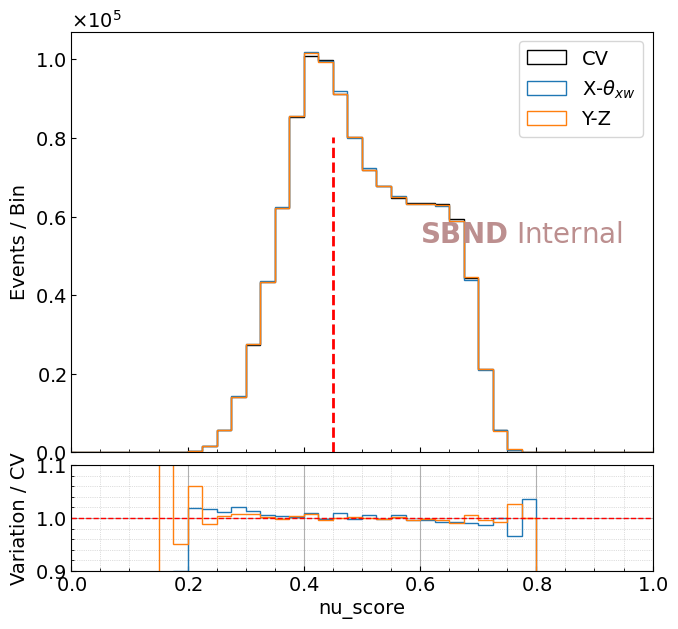

In [26]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]
var_name = ("slc","nu_score")
bins = np.linspace(0., 1., 41)
plot_labels = ["nu_score", pot_label, ""]
save_name = save_fig_dir + "/{}.png".format("nu_score")
n = detvar_plotter(evtdfs, 
                   var_name=var_name, 
                #    datadf=syst_dfs["data"],
                   bins=bins,
                   plot_labels=plot_labels,
                   vline=[NU_SCORE_TH],
                   save_fig=save_fig, save_name=save_name)

In [27]:
for syst_key in syst_keys + ["data"]:
    syst_dfs[syst_key] = cut_nu_score(syst_dfs[syst_key], NU_SCORE_TH)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9991005620411361
0.9987634521203497


In [29]:
syst_dfs_all = syst_dfs

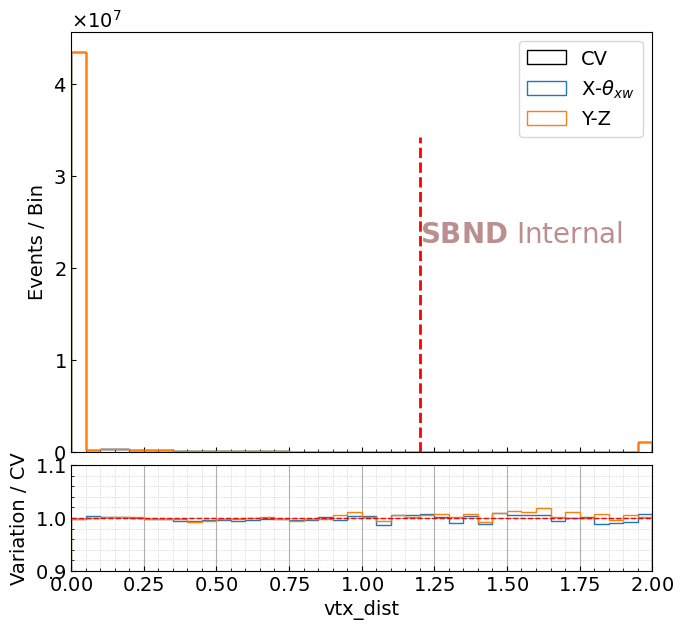

In [30]:
evtdfs = [syst_dfs[syst_key+"_trk"] for syst_key in syst_keys]
var_name = ("pfp","pfochar","vtxdist")
bins = np.linspace(0, 2, 41)
plot_labels = ["vtx_dist", pot_label, ""]
save_name = save_fig_dir + "vtx_dist"
n = detvar_plotter(evtdfs, 
                    var_name=var_name,
                    # datadf=syst_dfs["data_trk"],
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[VTXDIST_TH],
                    save_fig=save_fig, save_name=save_name)

In [31]:
for k in syst_keys+["data"]:
    syst_dfs[k] = get_trk_info(syst_dfs[k], syst_dfs[f'{k}_trk'], SAVE_NTRKS)
    del syst_dfs[f'{k}_trk']
# del mc_trk_df

/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/makedf/selections.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evtdf["n_trks"] = ntrks
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/makedf/selections.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evtdf["n_good_trks"] = ntrks


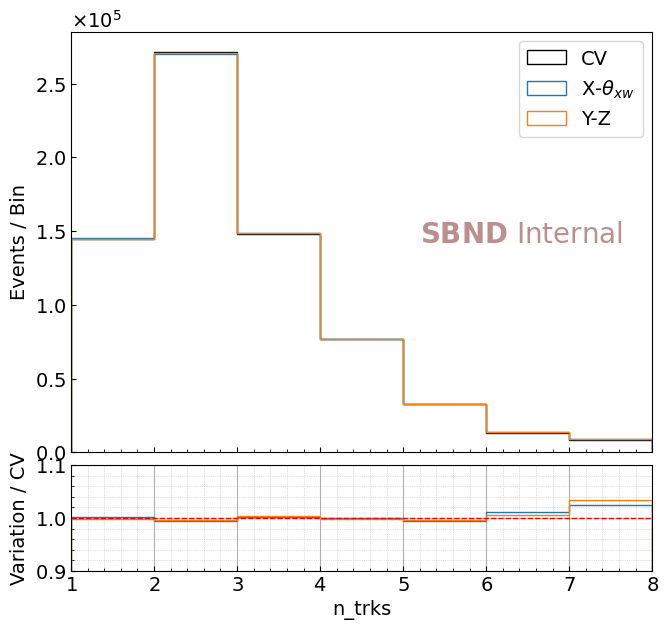

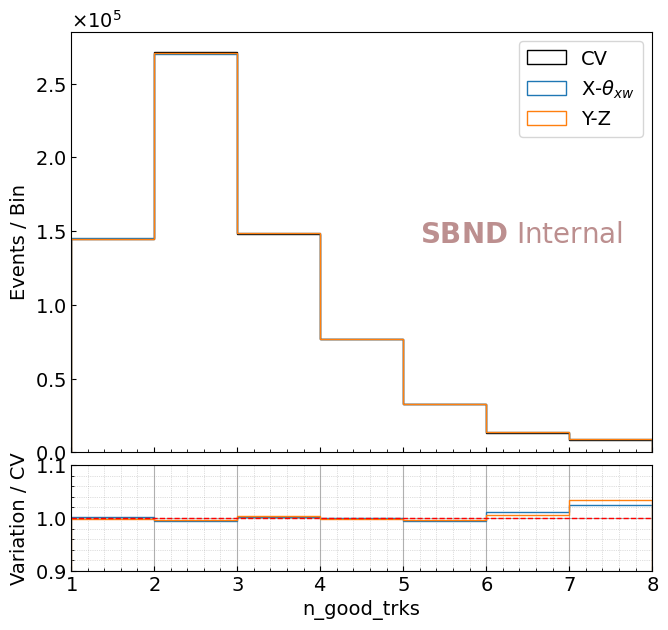

In [32]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]

var_name = "n_trks"
bins = np.linspace(1, 8, 8)
plot_labels = ["n_trks", pot_label, ""]
save_name = save_fig_dir + "n_trks"
n = detvar_plotter(evtdfs, 
                    # datadf=syst_dfs["data"],
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    save_fig=save_fig, save_name=save_name)

var_name = "n_good_trks"
bins = np.linspace(1, 8, 8)
plot_labels = ["n_good_trks", pot_label, ""]
save_name = save_fig_dir + "n_good_trks"
n = detvar_plotter(evtdfs, 
                    # datadf=syst_dfs["data"],
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    save_fig=save_fig, save_name=save_name)

In [33]:
for syst_key in syst_keys+["data"]:
    syst_dfs[syst_key] = cut_2prong(syst_dfs[syst_key])

for syst_key in syst_keys+["data"]:
    syst_dfs[syst_key] = cut_2prong_contained(syst_dfs[syst_key], det=DETECTOR)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9962564386440614
0.9945863786907856


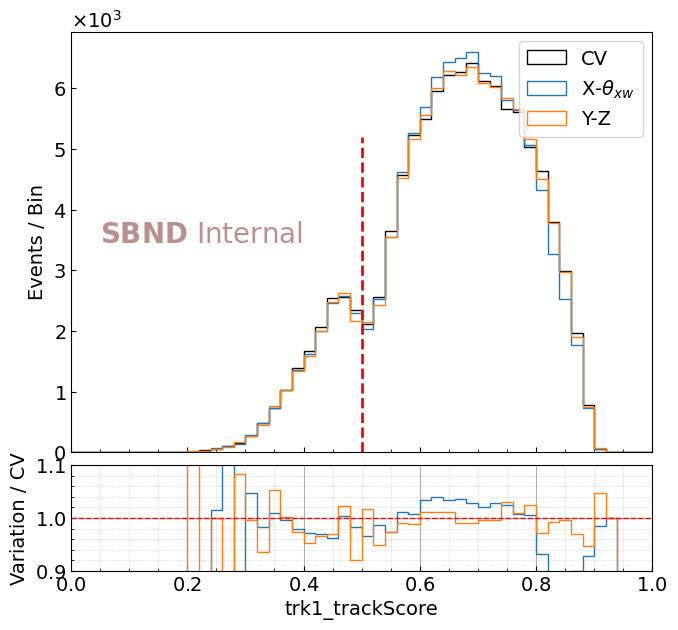

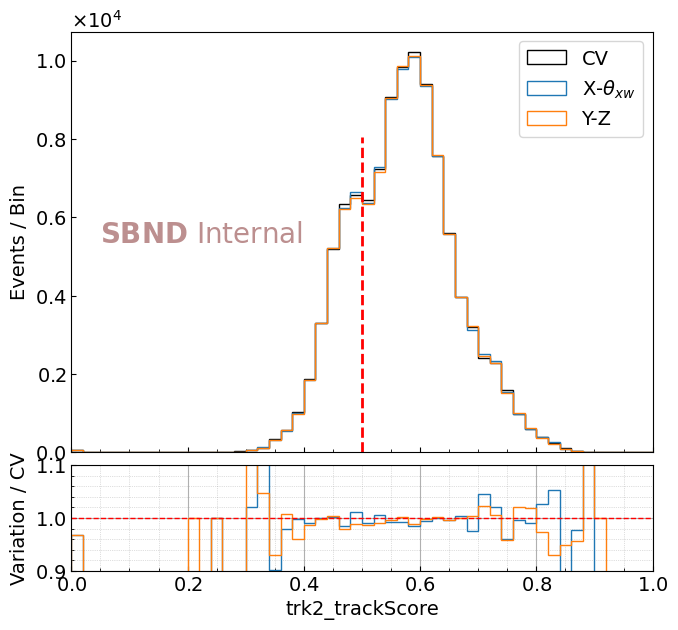

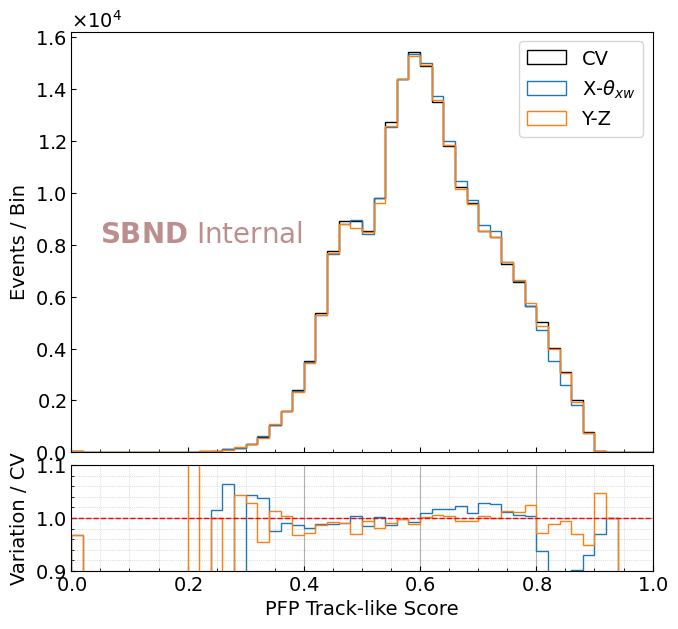

In [34]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trackScore")
    bins = np.linspace(0, 1, 51)
    save_tag = "trk{}_trackScore".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + save_tag
    n = detvar_plotter(evtdfs, 
                        # datadf=syst_dfs["data"],
                        var_name=var_name,
                        bins=bins,
                        plot_labels=plot_labels,
                        vline=[TRACKSCORE_TH],
                        save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = ["PFP Track-like Score", pot_label, ""]
save_tag = "both_trks_trackScore"
save_name = save_fig_dir + save_tag
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[MU_CHI2MU_TH],
                    save_fig=save_fig, save_name=save_name)

In [35]:
for syst_key in syst_keys+["data"]:
    syst_dfs[syst_key] = cut_2prong_trackscore(syst_dfs[syst_key], TRACKSCORE_TH)
    syst_dfs[syst_key] = cut_2prong_vtxdist(syst_dfs[syst_key], VTXDIST_TH)
    
for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9945678018802355
0.9973296265135165


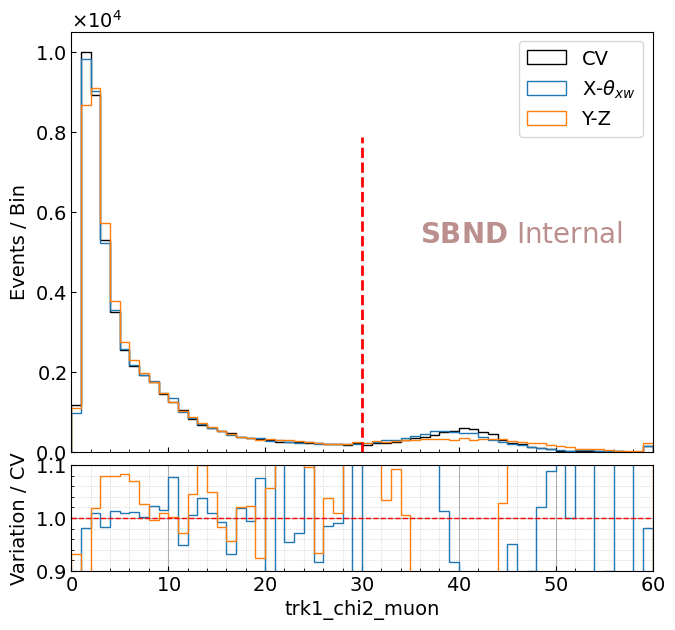

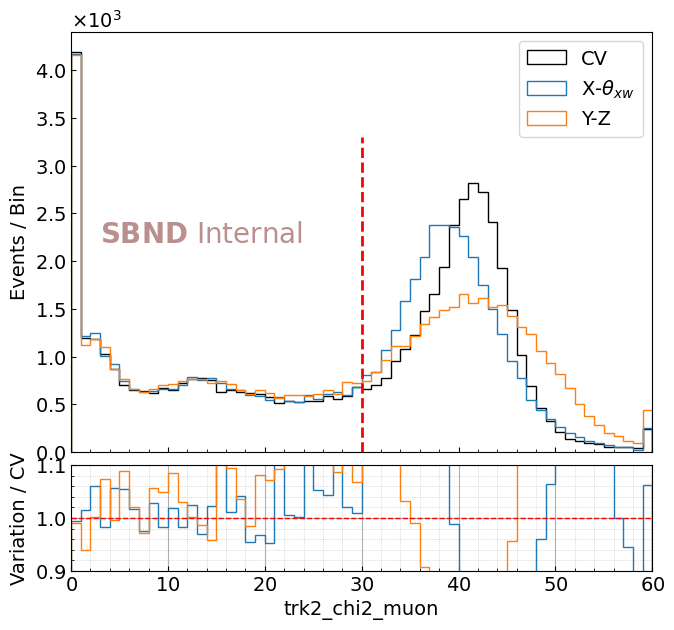

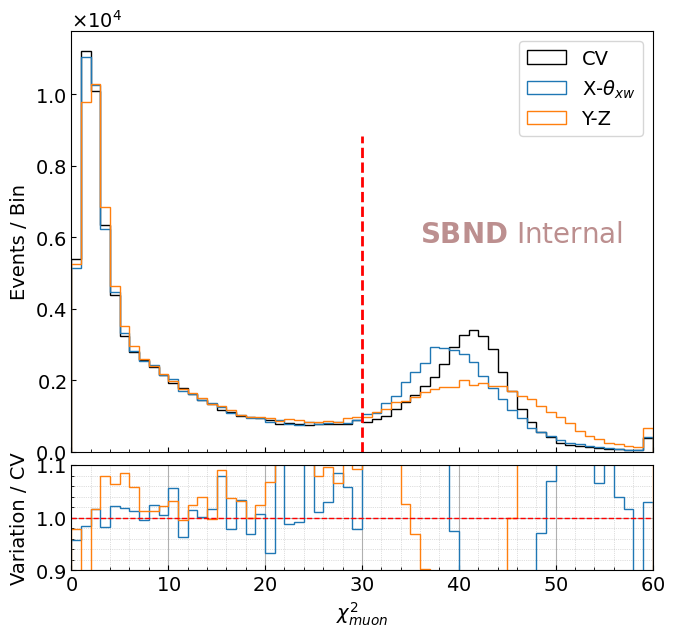

In [36]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "chi2pid", "I2", "chi2_muon")
    bins = np.linspace(0, 60, 61)
    save_tag = "trk{}_chi2_muon".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + save_tag
    n = detvar_plotter(evtdfs, 
                    #    datadf=syst_dfs["data"],
                       var_name=var_name,
                       bins=bins,
                       plot_labels=plot_labels,
                       vline=[MU_CHI2MU_TH],
                       save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = [r"$\chi^2_{muon}$", pot_label, ""]
save_tag = "both_trks_chi2_muon"
save_name = save_fig_dir + save_tag
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[MU_CHI2MU_TH],
                    save_fig=save_fig, save_name=save_name)

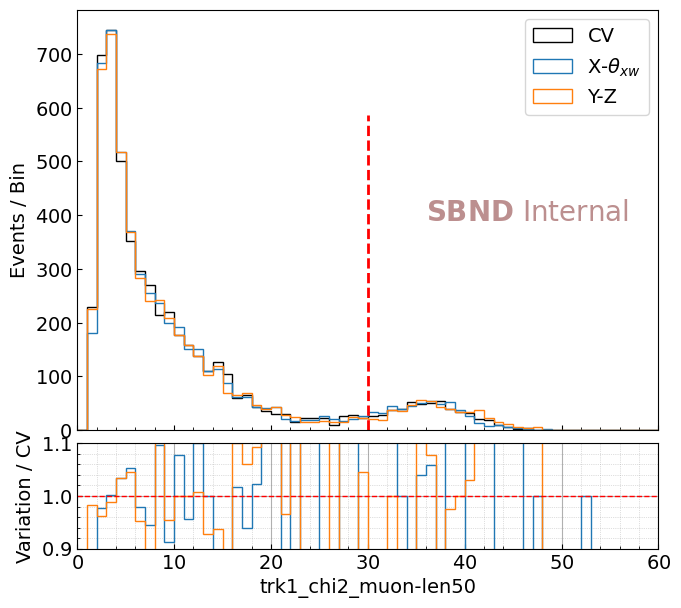

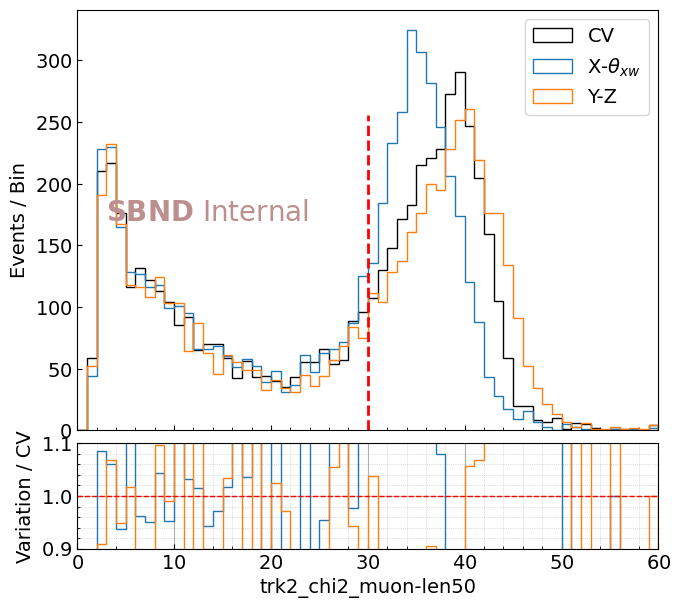

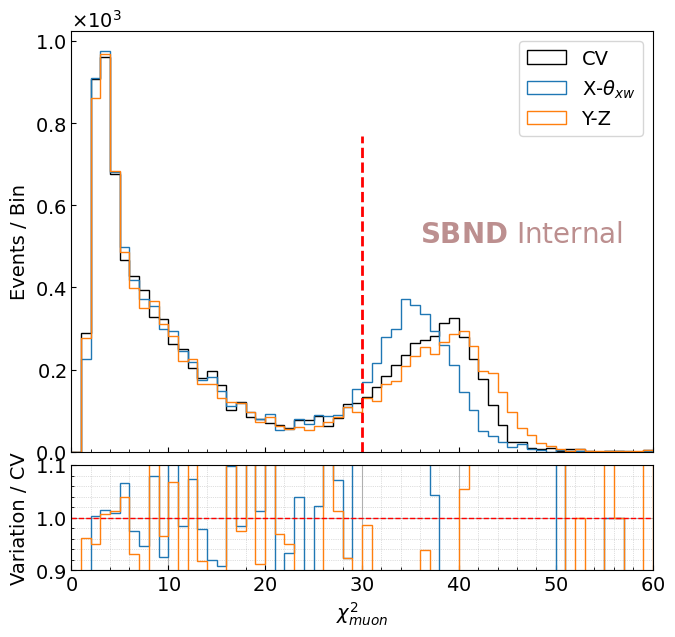

In [37]:
evtdfs = [syst_dfs[syst_key][(syst_dfs[syst_key].trk1.pfp.trk.len > 50) & (syst_dfs[syst_key].trk2.pfp.trk.len > 50)] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "chi2pid", "avg", "chi2_muon")
    bins = np.linspace(0, 60, 61)
    save_tag = "trk{}_chi2_muon-len50".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + save_tag
    n = detvar_plotter(evtdfs, 
                       var_name=var_name,
                       bins=bins,
                       plot_labels=plot_labels,
                       vline=[MU_CHI2MU_TH],
                       save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = [r"$\chi^2_{muon}$", pot_label, ""]
save_tag = "both_trks_chi2_muon-len50"
save_name = save_fig_dir + save_tag
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[MU_CHI2MU_TH],
                    save_fig=save_fig, save_name=save_name)

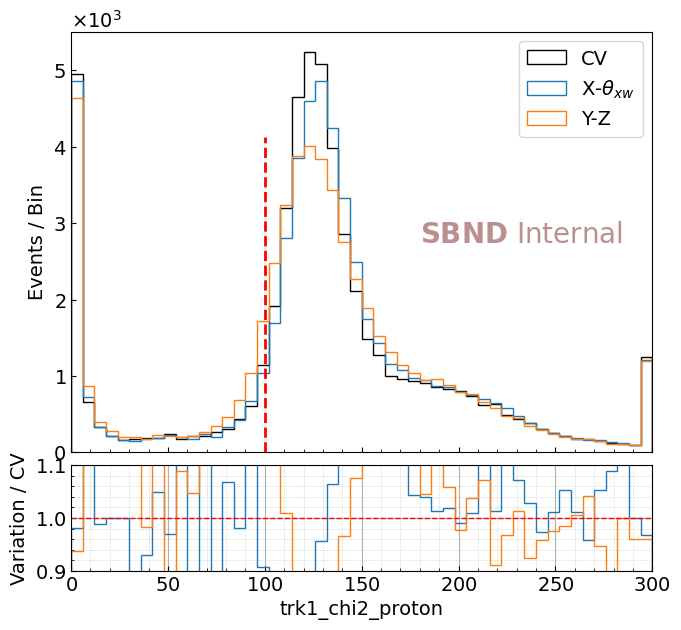

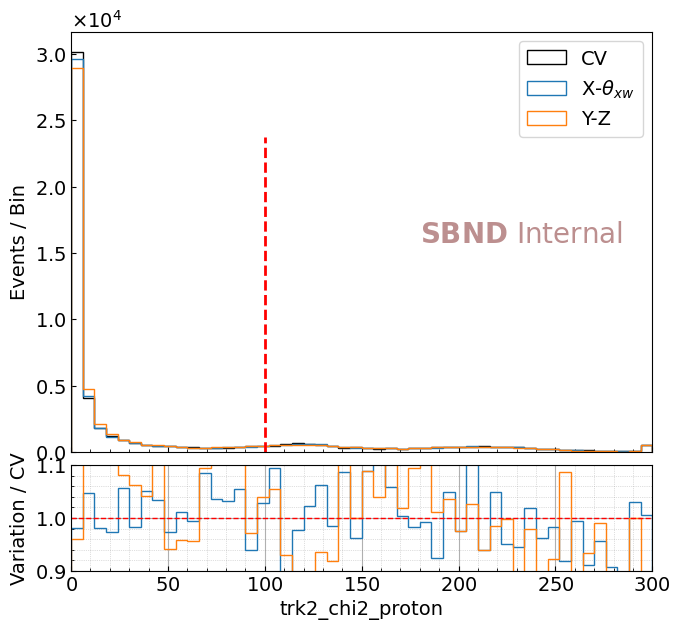

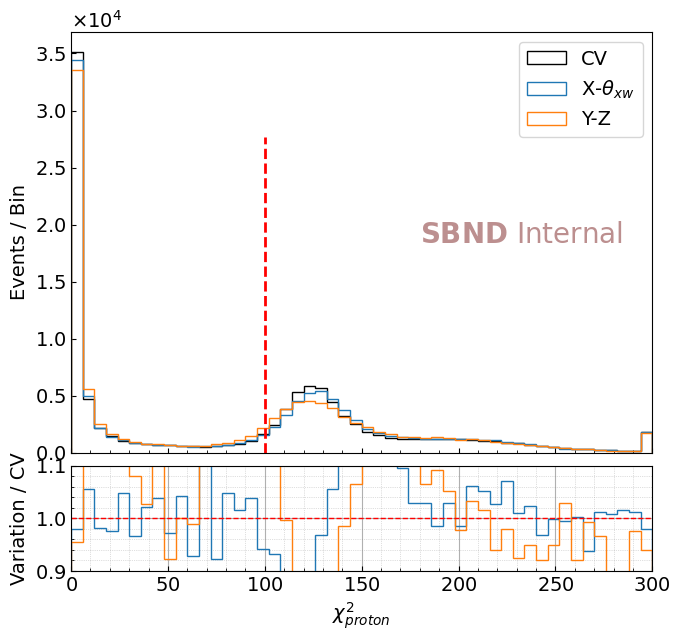

In [38]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "chi2pid", "I2", "chi2_proton")
    bins = np.linspace(0, 300, 51)
    save_tag = "trk{}_chi2_proton".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + save_tag
    n = detvar_plotter(evtdfs, 
                        var_name=var_name,
                        bins=bins,
                        plot_labels=plot_labels,
                        vline=[MU_CHI2P_TH],
                        save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = [r"$\chi^2_{proton}$", pot_label, ""]
save_tag = "both_trks_chi2_proton"
save_name = save_fig_dir + save_tag
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[MU_CHI2P_TH],
                    save_fig=save_fig, save_name=save_name)

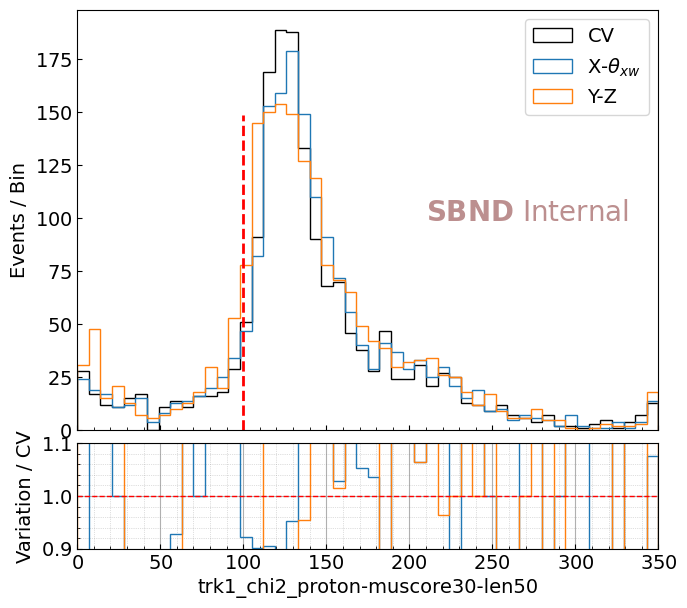

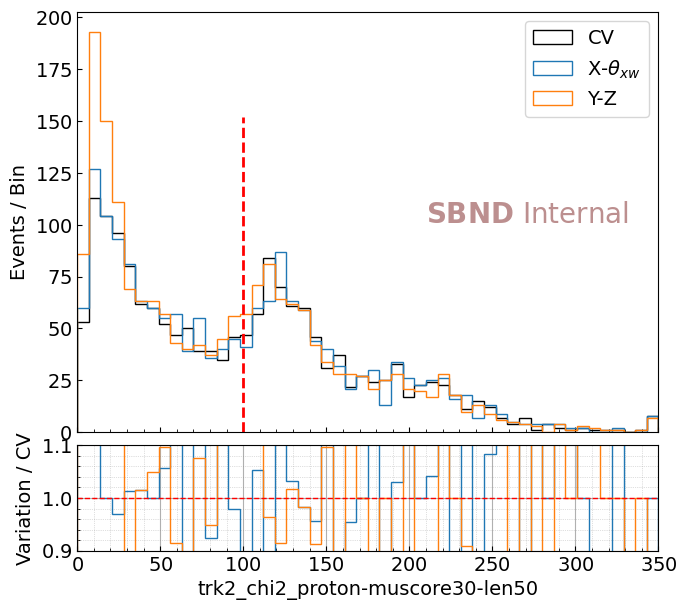

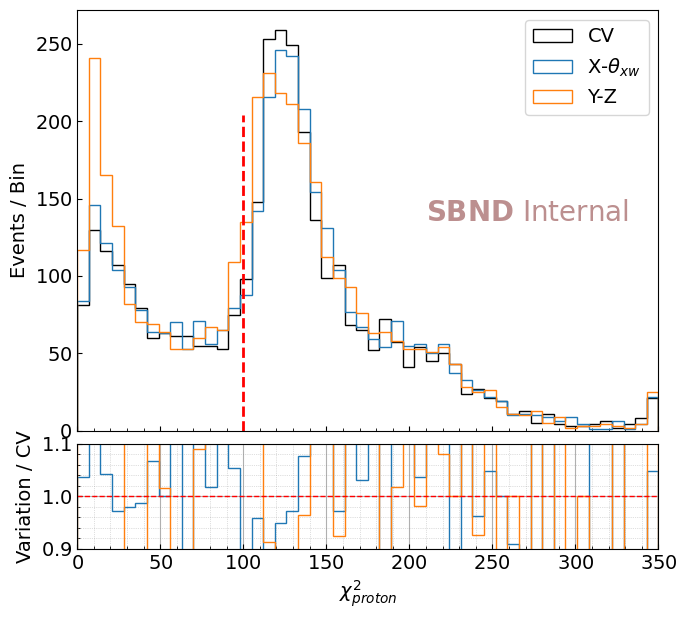

In [39]:
evtdfs = [syst_dfs[syst_key][(syst_dfs[syst_key].trk1.pfp.trk.chi2pid.I2.chi2_muon < 30) & (syst_dfs[syst_key].trk1.pfp.trk.len > 50) & (syst_dfs[syst_key].trk2.pfp.trk.chi2pid.I2.chi2_muon < 30) & (syst_dfs[syst_key].trk2.pfp.trk.len > 50)] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "chi2pid", "I2", "chi2_proton")
    bins = np.linspace(0, 350, 51)
    save_tag = "trk{}_chi2_proton-muscore30-len50".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + save_tag
    n = detvar_plotter(evtdfs, 
                        var_name=var_name,
                        bins=bins,
                        plot_labels=plot_labels,
                        vline=[MU_CHI2P_TH],
                        save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = [r"$\chi^2_{proton}$", pot_label, ""]
save_tag = "both_trks_chi2_proton-muscore30-len50"
save_name = save_fig_dir + "/{}.png".format(save_tag)
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[MU_CHI2P_TH],
                    save_fig=save_fig, save_name=save_name)

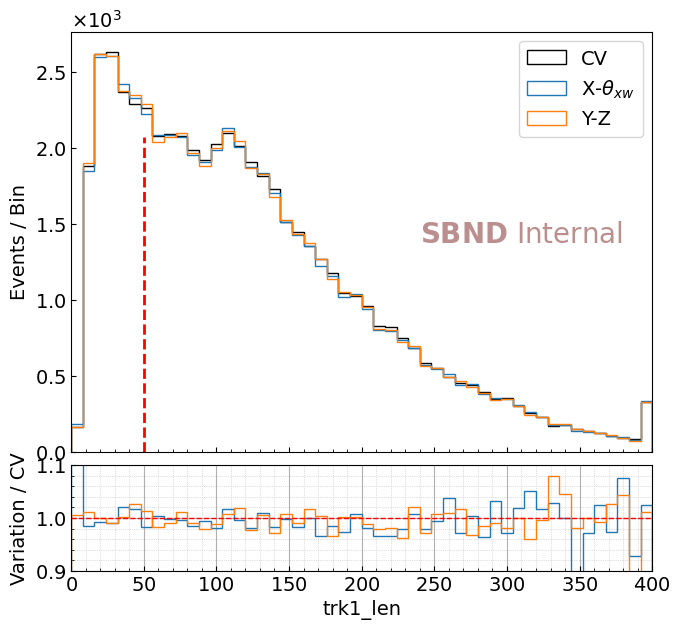

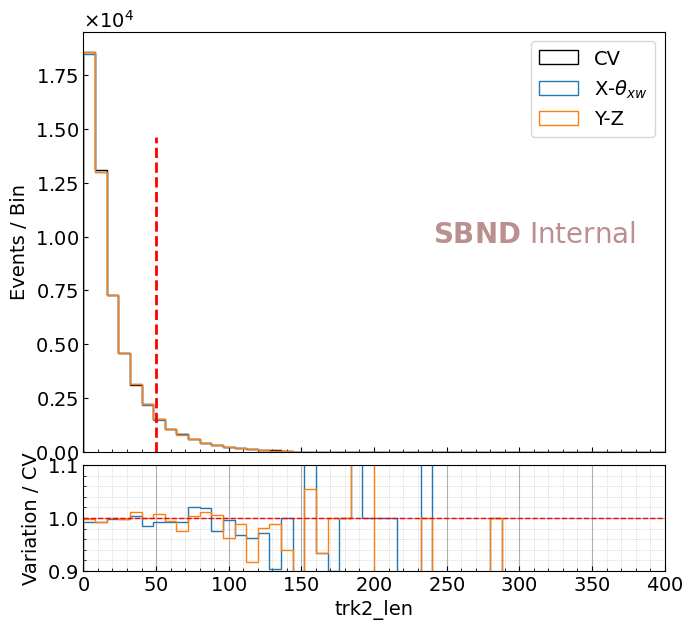

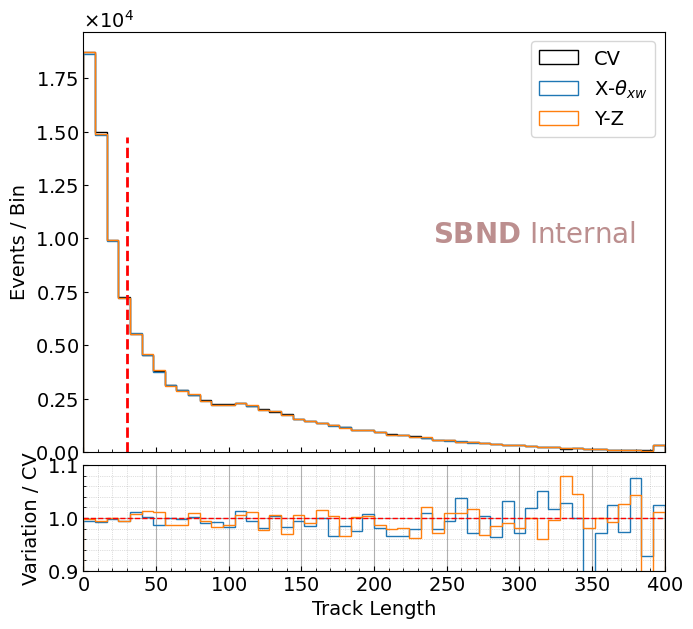

In [40]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "len")
    bins = np.linspace(0, 400, 51)
    save_tag = "trk{}_len".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + save_tag
    n = detvar_plotter(evtdfs, 
                        var_name=var_name,
                        bins=bins,
                        plot_labels=plot_labels,
                        vline=[MU_LEN_TH],
                        save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = ["Track Length", pot_label, ""]
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[MU_CHI2MU_TH],
                    save_fig=save_fig, save_name=save_name)

In [41]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = get_mu_p_candidate(syst_dfs[syst_key], 
                            mu_chi2mu_th=MU_CHI2MU_TH, mu_chi2p_th=MU_CHI2P_TH, mu_len_th=MU_LEN_TH, qual_th=QUAL_TH,
                            p_chi2mu_th=-1, p_chi2p_th=P_CHI2P_TH, p_len_th=P_LEN_TH)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9945678018802355
0.9973296265135165


In [42]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_has_mu(syst_dfs[syst_key]) 
    syst_dfs[syst_key] = cut_mu_kinematics(syst_dfs[syst_key], mu_Plo_th=MU_PLO_TH, mu_Phi_th=MU_PHI_TH)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9902781300194438
0.9936032913461268


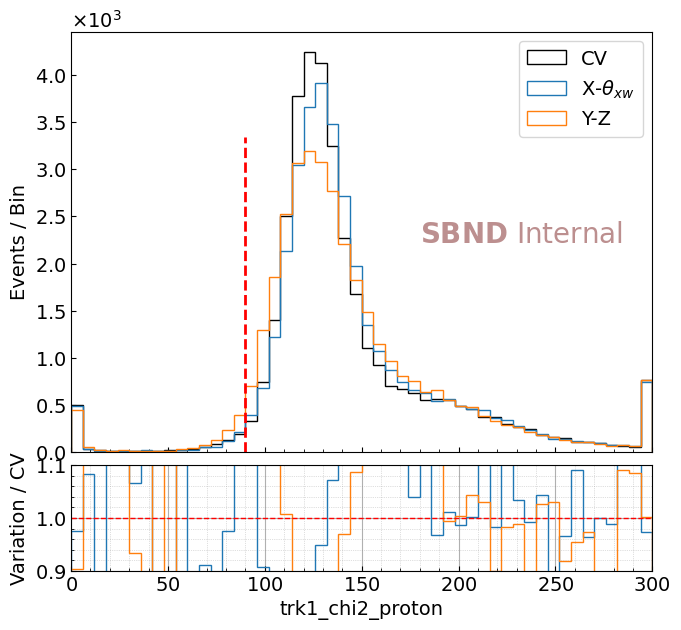

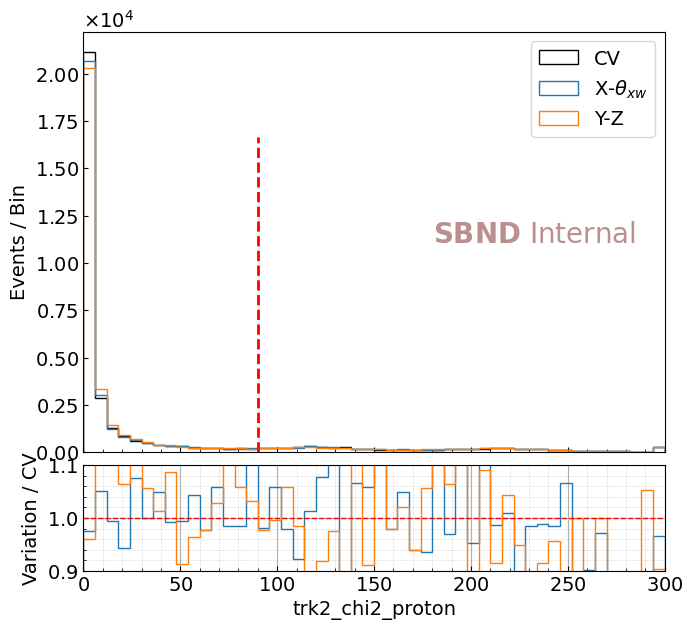

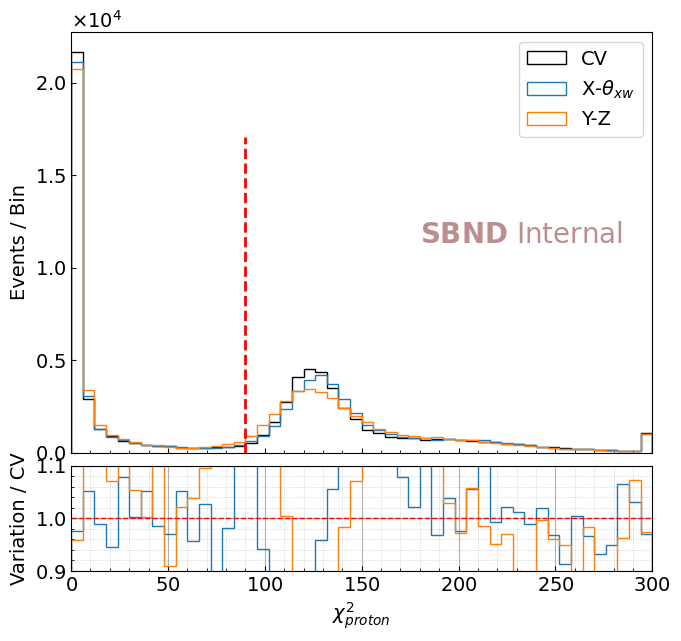

In [43]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "chi2pid", "I2", "chi2_proton")
    bins = np.linspace(0, 300, 51)
    save_tag = "trk{}_chi2_proton".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + save_tag
    n = detvar_plotter(evtdfs, 
                        var_name=var_name,
                        bins=bins,
                        plot_labels=plot_labels,
                        vline=[P_CHI2P_TH],
                        save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = [r"$\chi^2_{proton}$", pot_label, ""]
save_tag = "both_trks_chi2_proton_aftermucut"
save_name = save_fig_dir + save_tag
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[P_CHI2P_TH],
                    save_fig=save_fig, save_name=save_name)

In [44]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_has_p(syst_dfs[syst_key]) 
    syst_dfs[syst_key] = cut_p_kinematics(syst_dfs[syst_key], p_Plo_th=P_PLO_TH, p_Phi_th=P_PHI_TH)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9907563700667149
1.0052246603970743


In [45]:
detvar_weights = {}

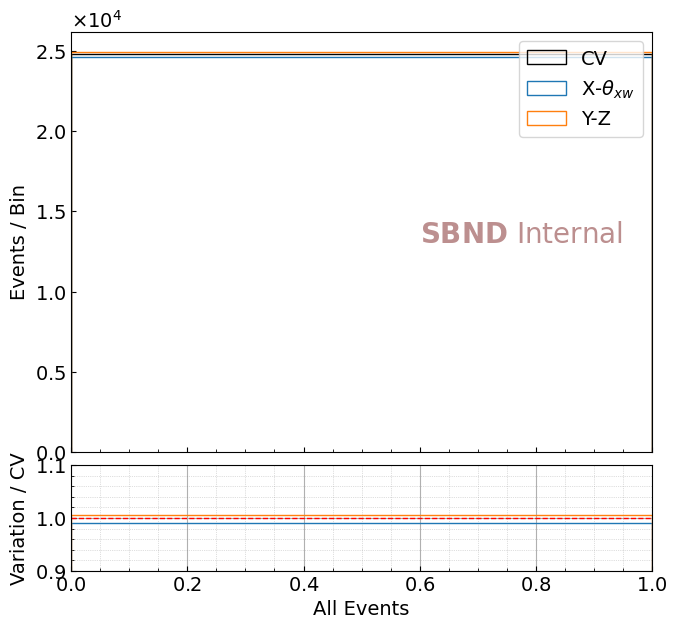

[24819. 24594. 24945.]


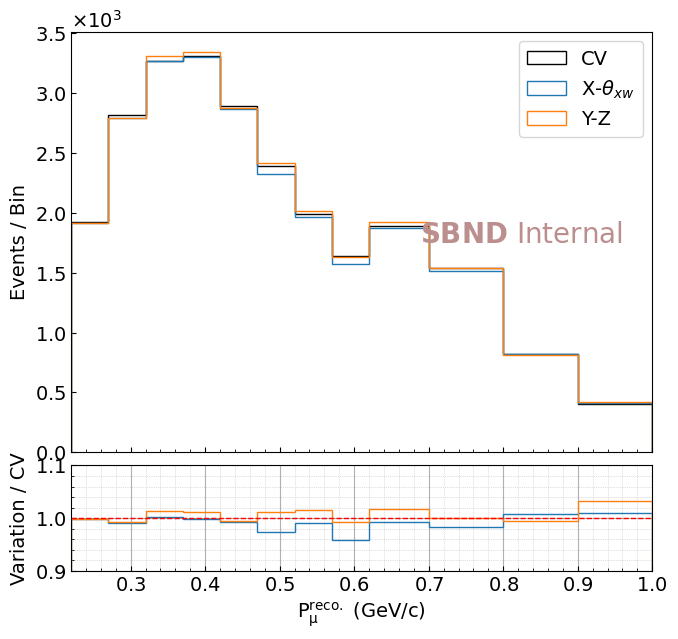

[24882. 24652. 25012.]


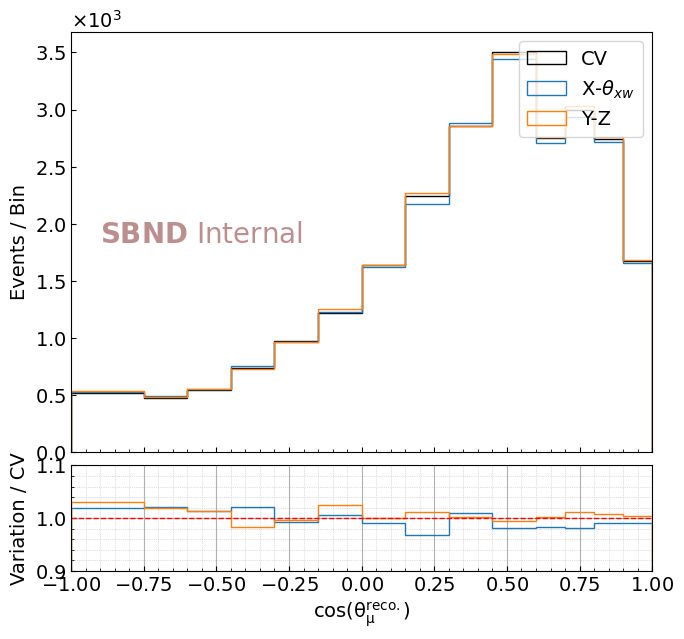

[24882. 24652. 25012.]


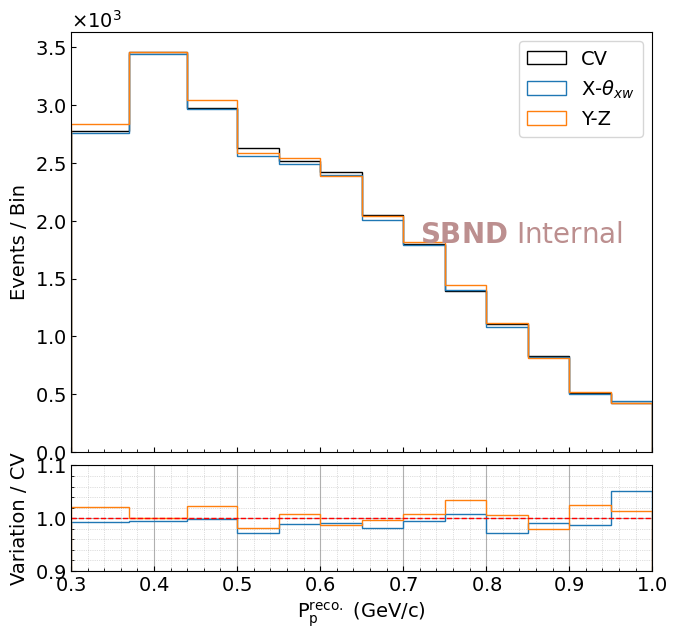

[24882. 24652. 25012.]


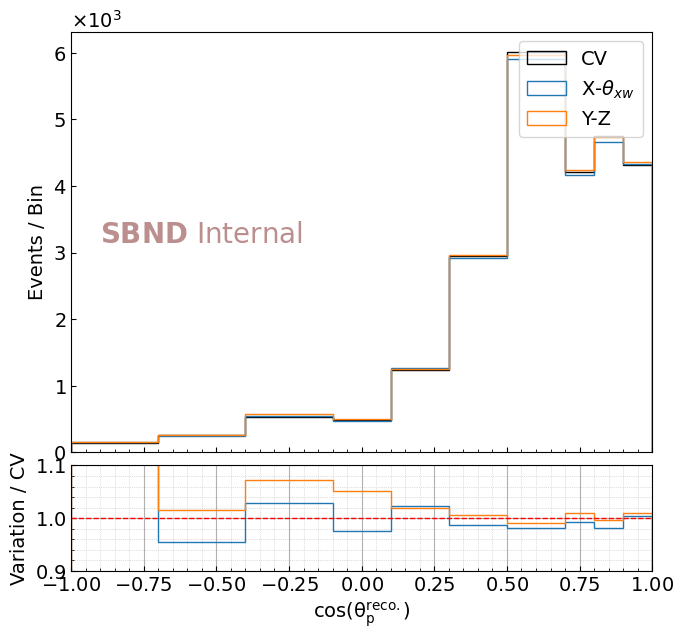

[24882. 24652. 25012.]


In [46]:
for var_config in [VariableConfig.all_events(), VariableConfig.muon_momentum(), VariableConfig.muon_direction(), VariableConfig.proton_momentum(), VariableConfig.proton_direction()]:
        evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]
        var_name = var_config.var_evt_reco_col
        bins = var_config.bins
        plot_labels = [var_config.var_labels[1], pot_label, ""]
        save_name = save_fig_dir + "/{}.png".format(var_config.var_save_name)
        n = detvar_plotter(evtdfs, 
                            var_name=var_name,
                            bins=bins,
                            plot_labels=plot_labels,
                            vline=[],
                            save_fig=save_fig, save_name=save_name)
        print(np.sum(n, axis=1))
        detvar_weights[var_config.var_save_name] = [n[i] for i in range(len(syst_keys))]

In [47]:
from pyanalib.variable_calculator import get_cc1p0pi_tki

tki_var_names = ["del_alpha", "del_phi", "del_Tp", "del_p", "del_Tp_x", "del_Tp_y"]
for syst_key in syst_keys:
    slc_mudf = syst_dfs[syst_key].mu.pfp.trk
    slc_pdf = syst_dfs[syst_key].p.pfp.trk
    slc_P_mu_col = pad_column_name(("P", "p_muon"), slc_mudf)
    slc_P_p_col = pad_column_name(("P", "p_proton"), slc_pdf)
    tki_reco = get_cc1p0pi_tki(slc_mudf, slc_pdf, slc_P_mu_col, slc_P_p_col)
    for var_name in tki_var_names:
        syst_dfs[syst_key] = multicol_add(syst_dfs[syst_key], tki_reco[var_name].rename(var_name))

In [48]:
for var_config in [VariableConfig.tki_del_Tp(), VariableConfig.tki_del_Tp_x(), VariableConfig.tki_del_Tp_y(), VariableConfig.tki_del_alpha(), VariableConfig.tki_del_phi()]:
        evtdfs = [syst_dfs[syst_key] for syst_key in syst_dfs.keys()]
        var_name = var_config.var_evt_reco_col
        bins = var_config.bins
        plot_labels = [var_config.var_labels[1], pot_label, ""]
        save_name = save_fig_dir + "/{}.png".format(var_config.var_save_name)
        n = detvar_plotter(evtdfs, 
                            var_name=var_name,
                            bins=bins,
                            plot_labels=plot_labels,
                            vline=[],
                            save_fig=save_fig, save_name=save_name)
        print(np.sum(n, axis=1))
        detvar_weights[var_config.var_save_name] = [n[i]/n[0] for i in range(len(syst_dfs.keys()))]

KeyError: ('del_Tp', '', '', '', '', '', '')

In [ ]:
# save to h5 file, use det var as the key
# note that these evtdfs have hdrdfs merged in

# save_filename = path.join(file_dir, "BNB_cosmics-sel_mup-{}.h5".format(this_variation))
# with pd.HDFStore(save_filename, "a") as store:
#     for syst_key in syst_dfs.keys():
#         print(syst_key)
#         store.put(syst_key, syst_dfs[syst_key])

# Detector Variation Systematic Uncertainty

In [ ]:
syst_name = "detvar"

In [ ]:
var_config = VariableConfig.muon_momentum()

In [ ]:
ret = signal_hists(syst_dfs['CV'], nudf=None, var_config=var_config, return_data=True, plot=True)
cv_events = ret["nevts_sel_reco"]

In [ ]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_dfs.keys()]
var_name = var_config.var_evt_reco_col
bins = var_config.bins
plot_labels = [var_config.var_labels[1], pot_label, ""]
approval = "internal"
save_name = save_fig_dir + "/{}.png".format(var_config.var_save_name)
n = detvar_plotter(evtdfs, 
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    approval=approval,
                    vline=[],
                    save_fig=save_fig, save_name=save_name)
detvar_weights[var_config.var_save_name] = [n[i]/n[0] for i in range(len(syst_dfs.keys()))]

In [ ]:
key_list = list(syst_dfs.keys())
kidx = 2
syst_name = key_list[kidx]
univ_events =np.array([cv_events + (n[kidx] - n[0])])

ret = get_covariance_matrix(univ_events, cv_events)

In [ ]:
plot_univ_hists(univ_events, cv_events, syst_name, var_config)

frac_unc = np.sqrt(np.diag(ret["cov_frac"]))
plot_frac_unc([frac_unc], var_config, plot_labels=[var_config.var_labels[1], var_config.var_labels[1], syst_name])

In [ ]:
matrix_type = "cov"
save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name, matrix_type)
title = "{} {}".format(syst_name, matrix_type)
plot_heatmap(ret[matrix_type], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Covariance"],
             save_fig=save_fig, save_name=save_fig_name)

In [ ]:
ret_dict = {}
for kidx, syst_key in enumerate(syst_dfs.keys()):
    if syst_key == "CV":
        continue

    # take syst variation as a unisim uncertainty
    cv_events = n[0]
    univ_events = np.array([n[kidx]]) 
    ret = get_covariance_matrix(univ_events, cv_events)
    ret_dict[syst_key] = ret
    plot_univ_hists(univ_events, 
                    cv_events,
                    syst_name, 
                    var_config)

    matrix_type = "cov"
    plot_labels = [var_config.var_labels[2], var_config.var_labels[1], ""]
    save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name, matrix_type)
    title = "{} {}".format(syst_key, matrix_type)
    plot_heatmap(ret[matrix_type], 
                 bins=bins,
                 plot_labels=plot_labels,
                 save_fig=save_fig, 
                 save_name=save_fig_name)

    frac_unc = np.sqrt(np.diag(ret["cov_frac"]))
    plot_frac_unc([frac_unc], var_config, plot_labels=["", "", syst_key])

In [ ]:
# get total detector variation covariance matrix
for kidx, syst_key in enumerate(ret_dict.keys()):
    if kidx == 0:
        detvar_total_cov = ret_dict[syst_key]["cov_frac"]
    else:
        detvar_total_cov += ret_dict[syst_key]["cov_frac"]

frac_unc = np.sqrt(np.diag(detvar_total_cov))
plot_frac_unc([frac_unc], var_config, plot_labels=["", "", "Total WireMod"])

# Save matrices

In [ ]:
# # ===== variables to process =====
# var_configs = [VariableConfig.all_events(),
#                 VariableConfig.muon_momentum(),
#                 VariableConfig.muon_direction(),
#                 VariableConfig.proton_momentum(),
#                 VariableConfig.proton_direction(),
#                VariableConfig.opening_angle(),
#                 VariableConfig.tki_del_alpha(),
#                 VariableConfig.tki_del_phi(),
#                 VariableConfig.tki_del_Tp(),
#                 VariableConfig.tki_del_p(),
#                 VariableConfig.tki_del_Tp_x(),
#                 VariableConfig.tki_del_Tp_y()]

# # ===== systs to process =====
# syst_names = ret_dict.keys()

# # ===== process systematics =====
# syst_dict = {} 

# for var_config in var_configs:
#     print(f"Processing {var_config.var_save_name}...")
#     for syst_name in syst_names:
#         print(f"Processing {syst_name}...")
#         matrices = ret_dict[syst_name]

#         if save_result:
#             syst_dict[var_config.var_save_name] = {
#                 syst_name[1]: matrices
#             }

# # ===== save results =====
# # print what we're saving
# print("saving dict with keys: ", syst_dict.keys())
# save_filename = f"{save_fig_dir}/detvar-{this_variation}_syst_dict.npz"
# print("saving syst_dict as npz in %s" % (save_filename))
# np.savez(save_filename, **syst_dict)